# Predictive Training Dashboard (STEP 6)

Real per-modality training on **held-out** sessions, via the label proxy system. Compare proxies and
modalities against baselines. **Technical PASS ≠ scientific GOOD** — GOOD requires beating `train_mean`
/ majority on held-out data. session_within_user alone is NOT final cognitive accuracy.

In [1]:
# === CONFIG ===
RUN         = False   # True -> launch training; False -> load existing results
DATA_DIR    = 'data_training_full_rebuilt'
MODALITIES  = ['mouse', 'keyboard', 'notif', 'switching']
LABEL_PROXY = 'nasa_tlx'   # nasa_tlx | nasa_time_weighted | dual_task_rt | hybrid_rt_nasa
SPLIT_MODE  = 'session_within_user'   # or 'loso'
EPOCHS, BATCH, LR, DEVICE, SEED = 200, 32, 1e-3, 'cuda', 42
import sys, json, subprocess
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT))
OUT = ROOT/'outputs/predictive_training'
def run_dir(proxy): return OUT/proxy/SPLIT_MODE
print('outputs dir:', OUT)

outputs dir: C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\predictive_training


In [2]:
if RUN:
    cmd = [sys.executable, str(ROOT/'scripts/predictive/train_predictive_experts.py'),
           '--data-dir', str(ROOT/DATA_DIR), '--output-dir', str(OUT), '--modalities', *MODALITIES,
           '--label-proxy', LABEL_PROXY, '--split-mode', SPLIT_MODE, '--epochs', str(EPOCHS),
           '--batch-size', str(BATCH), '--device', DEVICE, '--seed', str(SEED)]
    print(' '.join(cmd)); subprocess.run(cmd, check=True, cwd=str(ROOT))
else:
    print('Loading existing results.')

Loading existing results.


## Proxy × modality comparison (test MAE vs train_mean baseline)

In [3]:
cmp = OUT/f'proxy_comparison_{SPLIT_MODE}.csv'
if cmp.exists():
    df = pd.read_csv(cmp)
    display(df[['label_proxy','modality','test_mae','baseline_train_mean_mae','beats_train_mean','test_r2','classification_macro_f1','beats_majority']])
else:
    print('Run the multi-proxy runner first.')

,label_proxy,modality,test_mae,baseline_train_mean_mae,beats_train_mean,test_r2,classification_macro_f1,beats_majority
0,nasa_tlx,mouse,0.333468,0.218662,False,-1.146753,0.118919,False
1,nasa_tlx,keyboard,0.311265,0.218662,False,-0.978448,0.120219,False
2,nasa_tlx,notif,0.457975,0.218662,False,-2.965029,0.141065,True
3,nasa_tlx,switching,0.301942,0.218662,False,-0.879512,0.223758,True
4,nasa_time_weighted,mouse,0.337347,0.218662,False,-1.187272,0.122340,False
5,nasa_time_weighted,keyboard,0.313909,0.218662,False,-1.003398,0.120879,False
6,nasa_time_weighted,notif,0.477919,0.218662,False,-3.258349,0.107154,False
7,nasa_time_weighted,switching,0.428874,0.218662,False,-2.577896,0.225623,True
8,dual_task_rt,mouse,0.206494,0.241564,True,0.048010,NaN,NaN
9,dual_task_rt,keyboard,0.274526,0.241564,False,-0.522106,NaN,NaN


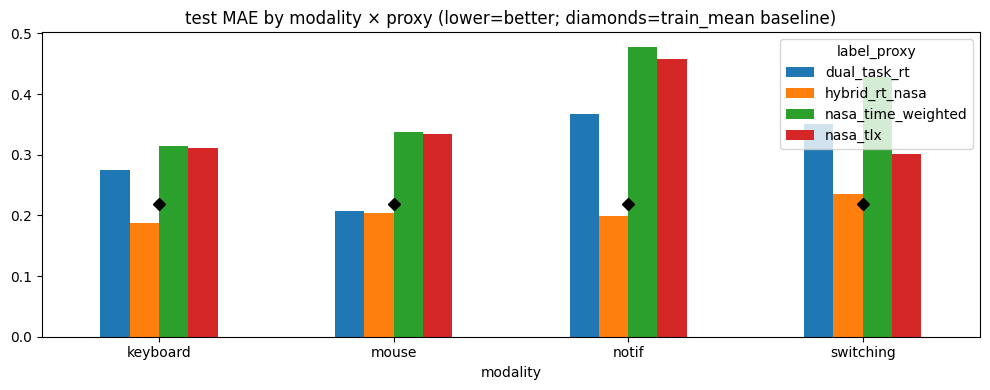

In [4]:
if cmp.exists():
    piv = df.pivot(index='modality', columns='label_proxy', values='test_mae')
    base = df.groupby('modality')['baseline_train_mean_mae'].first()
    ax = piv.plot(kind='bar', figsize=(10,4)); base.plot(style='kD', ax=ax, label='train_mean')
    ax.set_title('test MAE by modality × proxy (lower=better; diamonds=train_mean baseline)'); plt.tight_layout(); plt.show()

## Detail for the chosen proxy (loss, metrics, baselines, plots)

In [5]:
rd = run_dir(LABEL_PROXY)
rs = json.load(open(rd/'run_summary.json'))
print('proxy:', LABEL_PROXY, '| split:', SPLIT_MODE, '| train/val/test:', rs['n_train'], rs['n_val'], rs['n_test'],
      '| users:', rs['n_users'], '| coverage%:', rs['coverage'])
pd.DataFrame(rs['modalities'])[['modality','status','test_mae','baseline_train_mean_mae','beats_train_mean','test_r2','classification_macro_f1','beats_majority']]

proxy: nasa_tlx | split: session_within_user | train/val/test: 575 89 142 | users: 13 | coverage%: 100.0


,modality,status,test_mae,baseline_train_mean_mae,beats_train_mean,test_r2,classification_macro_f1,beats_majority
0,mouse,PASS,0.333468,0.218662,False,-1.146753,0.118919,False
1,keyboard,PASS,0.311265,0.218662,False,-0.978448,0.120219,False
2,notif,PASS,0.457975,0.218662,False,-2.965029,0.141065,True
3,switching,PASS,0.301942,0.218662,False,-0.879512,0.223758,True


============================== mouse ==============================


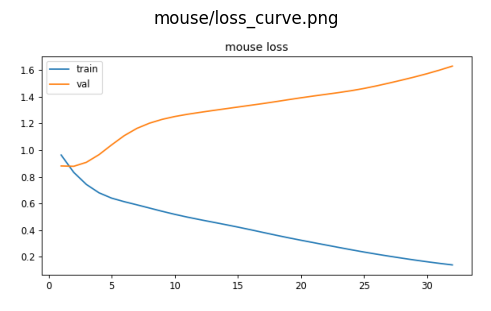

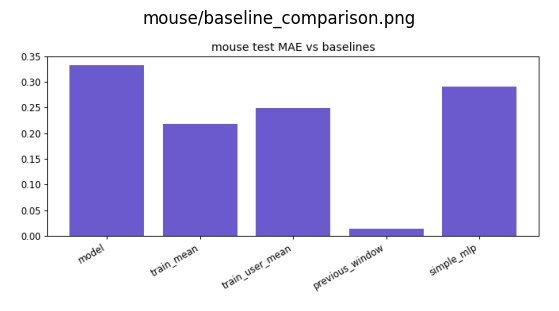

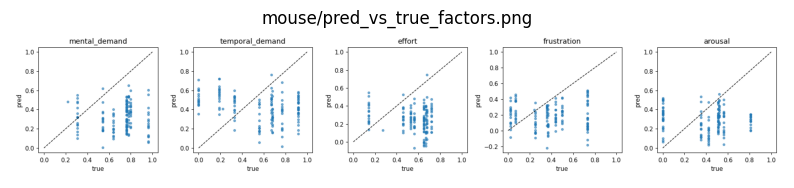

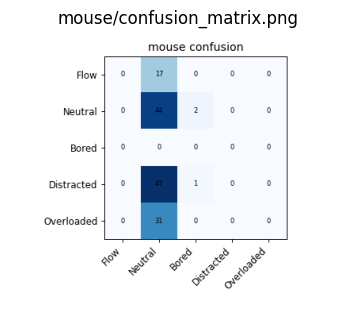

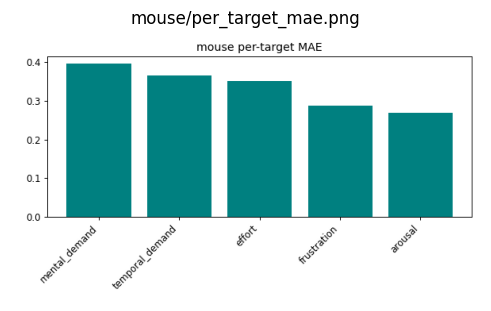

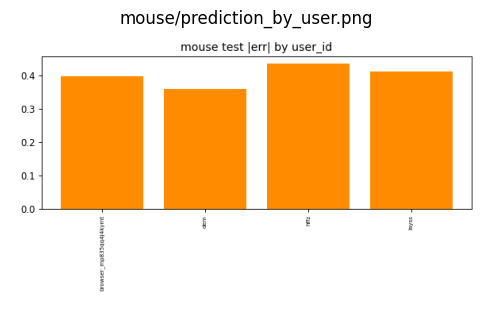

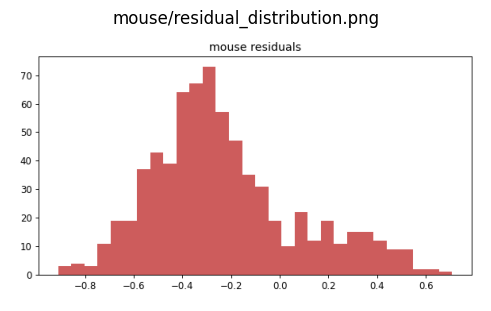

============================== keyboard ==============================


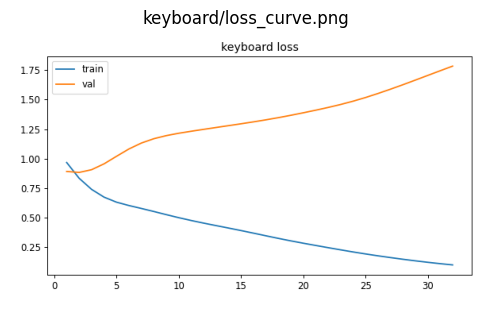

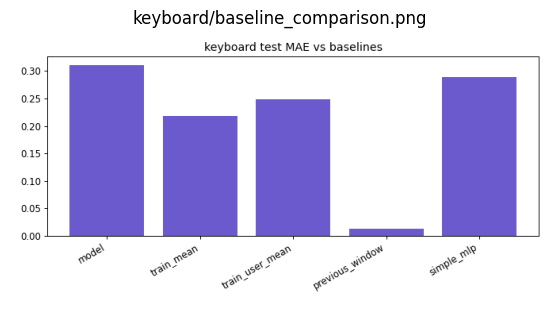

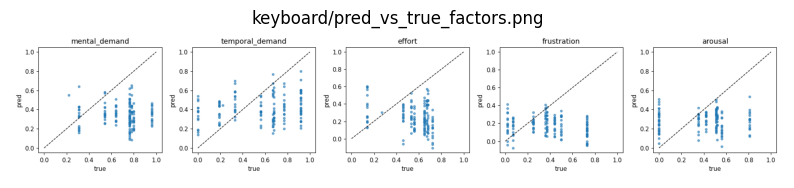

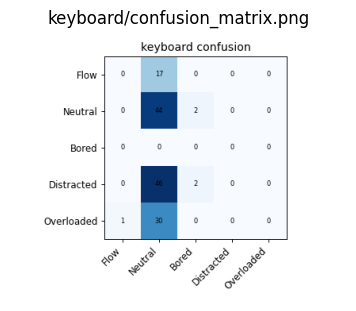

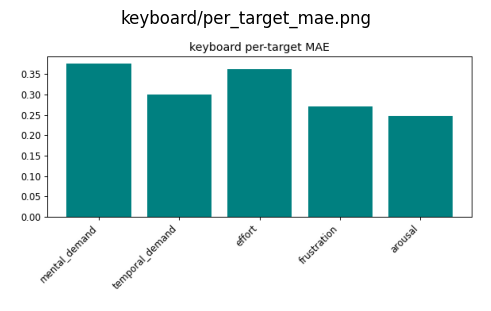

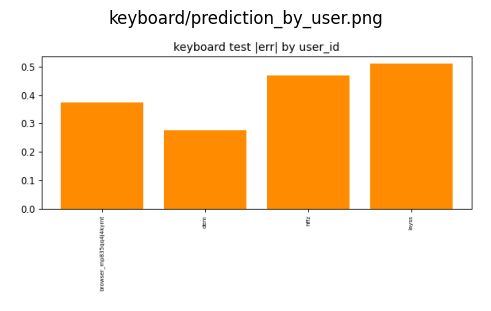

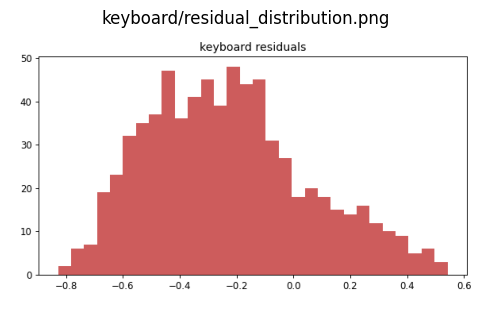

============================== notif ==============================


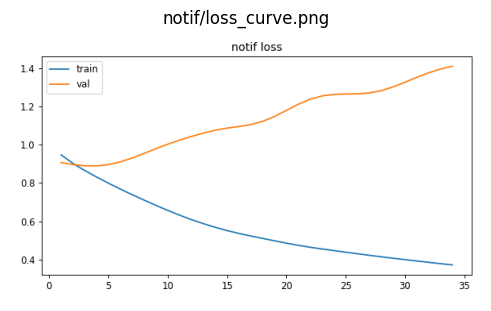

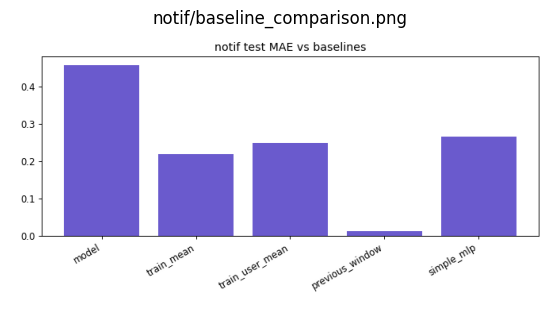

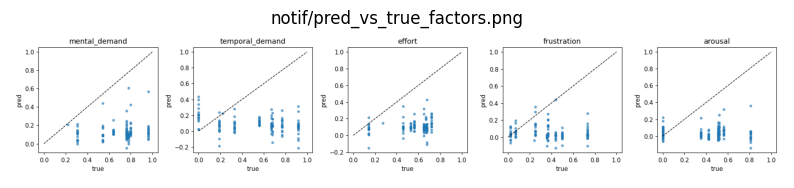

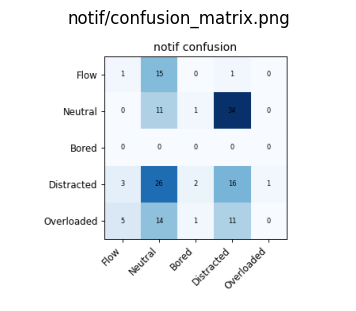

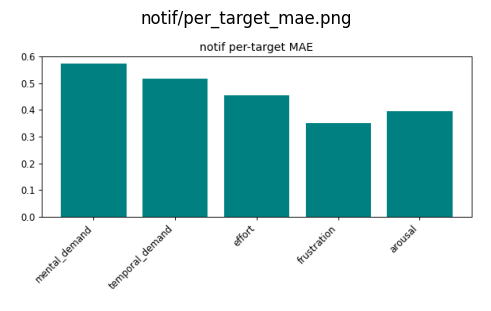

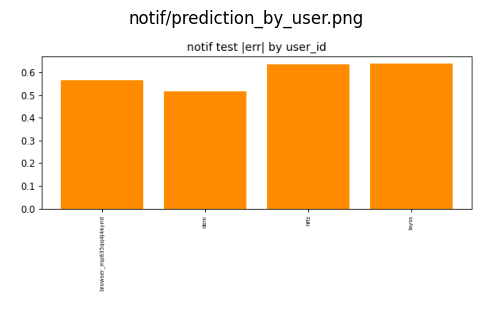

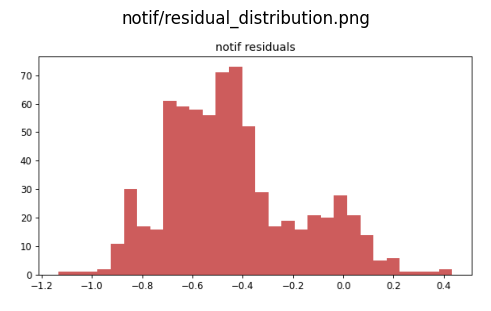

============================== switching ==============================


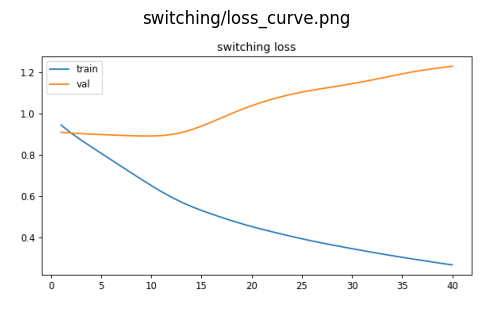

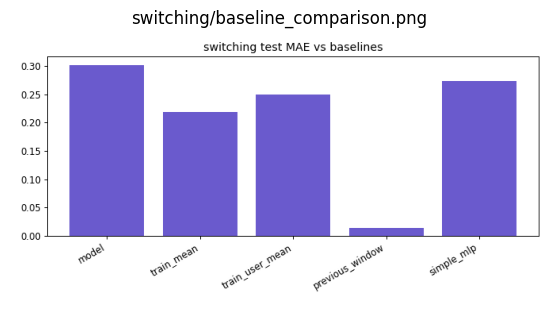

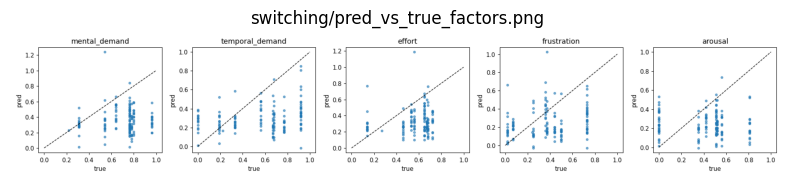

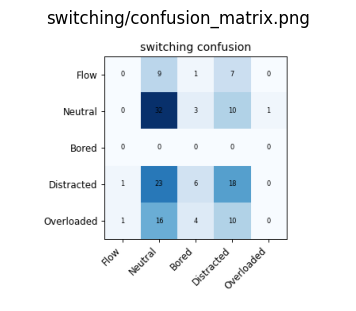

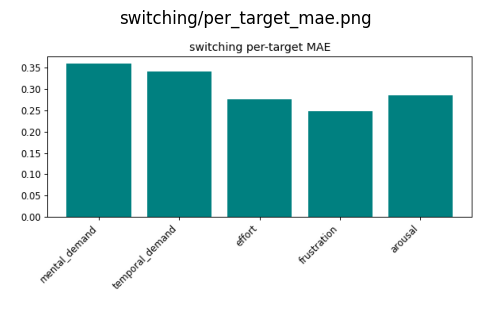

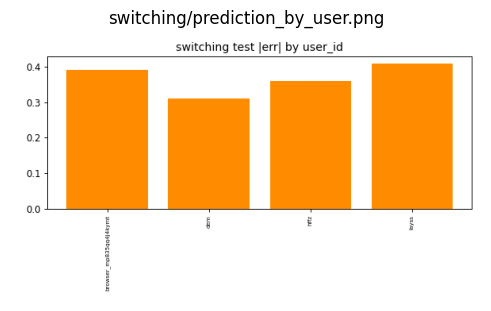

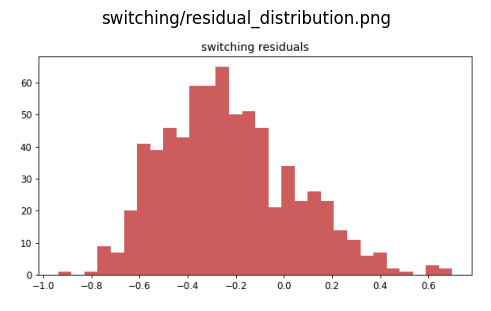

In [6]:
def show(modality):
    pdir = run_dir(LABEL_PROXY)/modality/'plots'
    for im in ['loss_curve.png','baseline_comparison.png','pred_vs_true_factors.png','pred_vs_true_scalar.png',
               'confusion_matrix.png','per_target_mae.png','prediction_by_user.png','residual_distribution.png']:
        p = pdir/im
        if p.exists():
            plt.figure(figsize=(10,3.5)); plt.imshow(Image.open(p)); plt.axis('off'); plt.title(f'{modality}/{im}'); plt.show()
for m in MODALITIES:
    print('='*30, m, '='*30); show(m)

## Interpretation
- **beats_train_mean=True** on test ⇒ the modality learns something generalizable for that proxy.
- Negative R² / not beating baseline ⇒ no useful held-out signal (do not over-interpret a low MAE alone).
- Read with the caveats: NASA is session-level, dual-task is sparse (~26%), keyboard is 57.6% fallback,
  hybrid mixes weakly-disagreeing signals. See `PREDICTIVE_TRAINING_STEP6_REPORT.md`.